## Imports

In [48]:
from datasets                        import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics                 import confusion_matrix
from sklearn.metrics                 import ConfusionMatrixDisplay
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import MultinomialNB
from sklearn.metrics                 import accuracy_score

import matplotlib.pyplot as plt

## Investigação inicial dos dados

In [49]:
dados = load_dataset("imdb")
print(dados.keys())

dict_keys(['train', 'test', 'unsupervised'])


In [50]:
print(dados)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Os dados do IMDb, nesse caso, não estão como um DataFrame Pandas ou um array de NumPy, e sim como um dicionário com 3 chaves:
- train: dados para treinar o modelo
- test: dados para testar o modelo
- unsupervised: dados sem rótulo, para modelos não supervisionados

Será usado nesse projeto o modelo TF-IDF para transformar e extrair as features, que serão usadas no modelo, na etapa seguinte, para classificação do texto (review positiva ou review negativa).

In [51]:
dados_treino = dados["train"]
dados_teste = dados["test"]

x_treino = [x["text"] for x in dados_treino]
y_treino = [y["label"] for y in dados_treino]

x_teste = [x["text"] for x in dados_teste]
y_teste = [y["label"] for y in dados_teste]

In [52]:
print(dados_treino[0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Label = 0 está indicando um review negativo, enquanto que o label = 1 indica um review positivo.

## Tokenização
Essa etapa consiste em transformar um texto em um vetor.

Como o `TfidfVectorizer` já realiza automaticamente algumas etapas básicas de pré-processamento de texto, essa etapa foi simplificada.  

In [53]:
vetorizar = TfidfVectorizer()

vetor_x_treino = vetorizar.fit_transform(x_treino)
vetor_x_teste = vetorizar.transform(x_teste)

In [54]:
print(vetorizar.vocabulary_)

{'rented': 54903, 'am': 2906, 'curious': 16037, 'yellow': 74187, 'from': 26180, 'my': 44639, 'video': 71281, 'store': 63396, 'because': 6459, 'of': 46680, 'all': 2662, 'the': 66339, 'controversy': 14602, 'that': 66322, 'surrounded': 64667, 'it': 34683, 'when': 72753, 'was': 72196, 'first': 24750, 'released': 54664, 'in': 33004, '1967': 372, 'also': 2821, 'heard': 30282, 'at': 4753, 'seized': 58675, 'by': 9962, 'customs': 16120, 'if': 32517, 'ever': 22737, 'tried': 68145, 'to': 67125, 'enter': 22039, 'this': 66562, 'country': 15124, 'therefore': 66437, 'being': 6663, 'fan': 23699, 'films': 24581, 'considered': 14309, 'controversial': 14598, 'really': 53839, 'had': 29369, 'see': 58585, 'for': 25450, 'myself': 44671, 'br': 8724, 'plot': 50428, 'is': 34585, 'centered': 11333, 'around': 4297, 'young': 74334, 'swedish': 64871, 'drama': 19970, 'student': 63767, 'named': 44850, 'lena': 38338, 'who': 72904, 'wants': 72096, 'learn': 38118, 'everything': 22770, 'she': 59426, 'can': 10357, 'about'

Com isso, o modelo de tokenização TF-IDF aprendeu o vocabulário de treino e converteu os dados de treino num vetor: `vetor_x_treino`.

Com esse vocabulário de treino, os dados de teste também foram vetorizados. Agora basta alimentar esses dados ao modelo de machine-learning.

## Treino dos modelos
Nessa seção, serão treinados os modelos de Naive-Bayes e Regressão logística.

Acurácia do modelo de Regressão Logística: 88.29 %


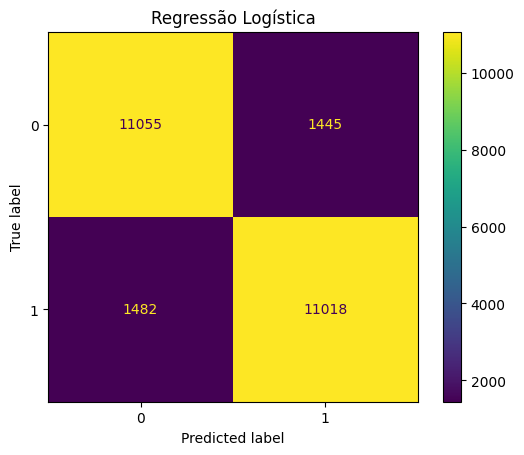

Acurácia do modelo de Naive Bayes: 82.96 %


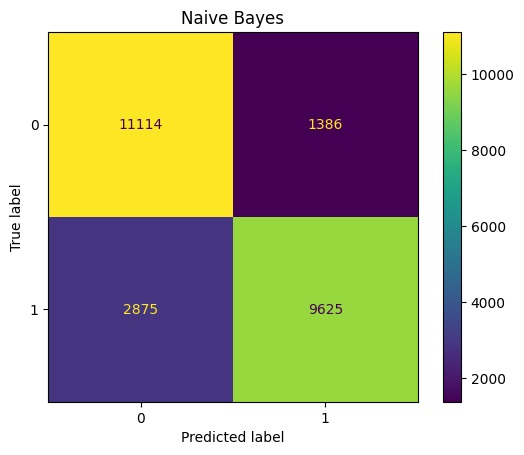

In [55]:
modelos = {
    "Regressão Logística": LogisticRegression(random_state=44),
    "Naive Bayes": MultinomialNB()
}

for nome_modelo, modelo in modelos.items():
    modelo.fit(vetor_x_treino, y_treino)
    previsoes = modelo.predict(vetor_x_teste)
    acuracia_modelo = accuracy_score(y_teste, previsoes) * 100
    print(f"Acurácia do modelo de {nome_modelo}: {acuracia_modelo:.2f} %")
    
    confusion_matrix(y_teste, previsoes)
    ConfusionMatrixDisplay.from_predictions(y_teste, previsoes)
    plt.title(f"{nome_modelo}")
    plt.show()